# Comparing all of the methods we used in order to evaluate the QDs

In [6]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk
from scipy.ndimage import gaussian_filter, median_filter

In [7]:
%%capture
%run "./npy-data-QD-DETECTION.ipynb"

In [8]:
%%capture
%run "./npy-data-QD-ANALYSIS.ipynb" 

Comparing dot detection within all of the methods

# Preprocessing and uploading the data

**1. Ground truth outputs across the 3 AFM images**

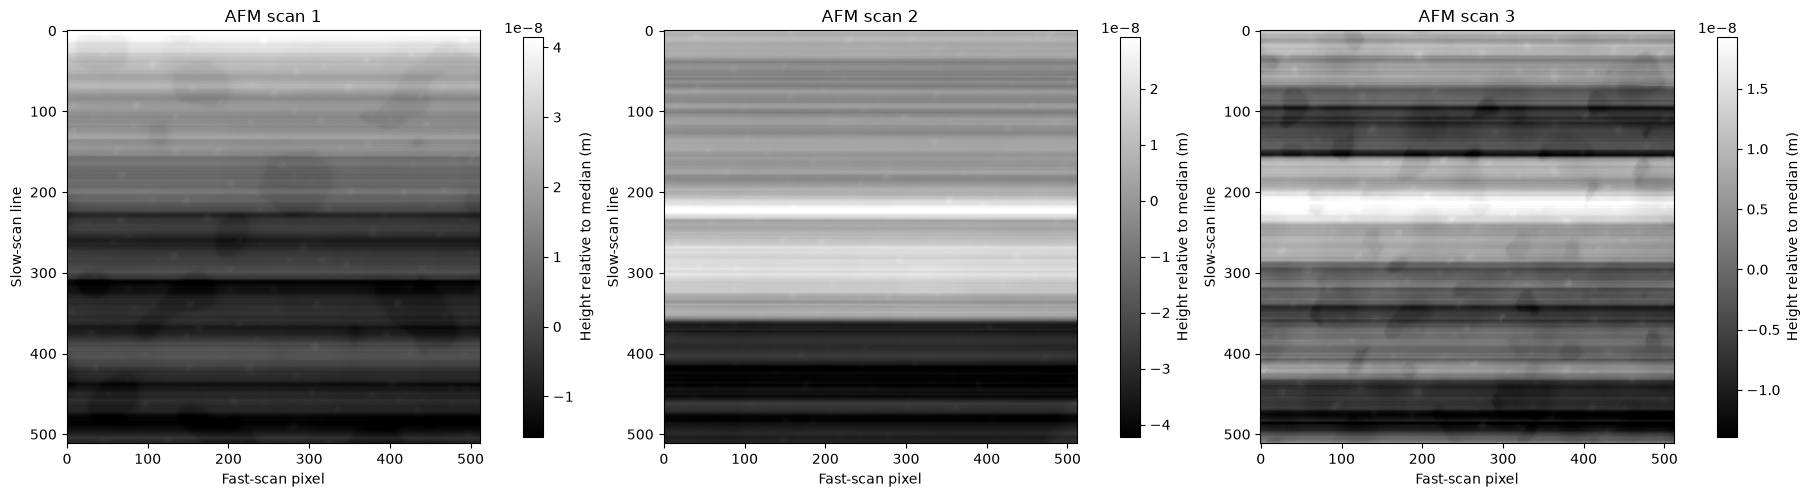

In [9]:
import matplotlib.pyplot as plt
import numpy as np

import data_preprocessing as dp

afm_files = [
    Path("Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data.npy"),
    Path("Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data.npy"),
    Path("Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data.npy"),
]

titles = [ "AFM scan 1", "AFM scan 2", "AFM scan 3",]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True,)

for ax, path, title in zip(axes, afm_files, titles):
    z = np.load(path)
    z = np.asarray(z, dtype=float)

    # Centre the height data around zero.
    z_display = z - np.nanmedian(z)

    # Robust display contrast.
    vmin, vmax = np.nanpercentile(z_display, [1, 99],)

    image = ax.imshow(z_display, cmap="gray", vmin=vmin, vmax=vmax, origin="upper",)

    ax.set_title(title)
    ax.set_xlabel("Fast-scan pixel")
    ax.set_ylabel("Slow-scan line")

    fig.colorbar(image, ax=ax, label="Height relative to median (m)", shrink=0.85,)

plt.show()

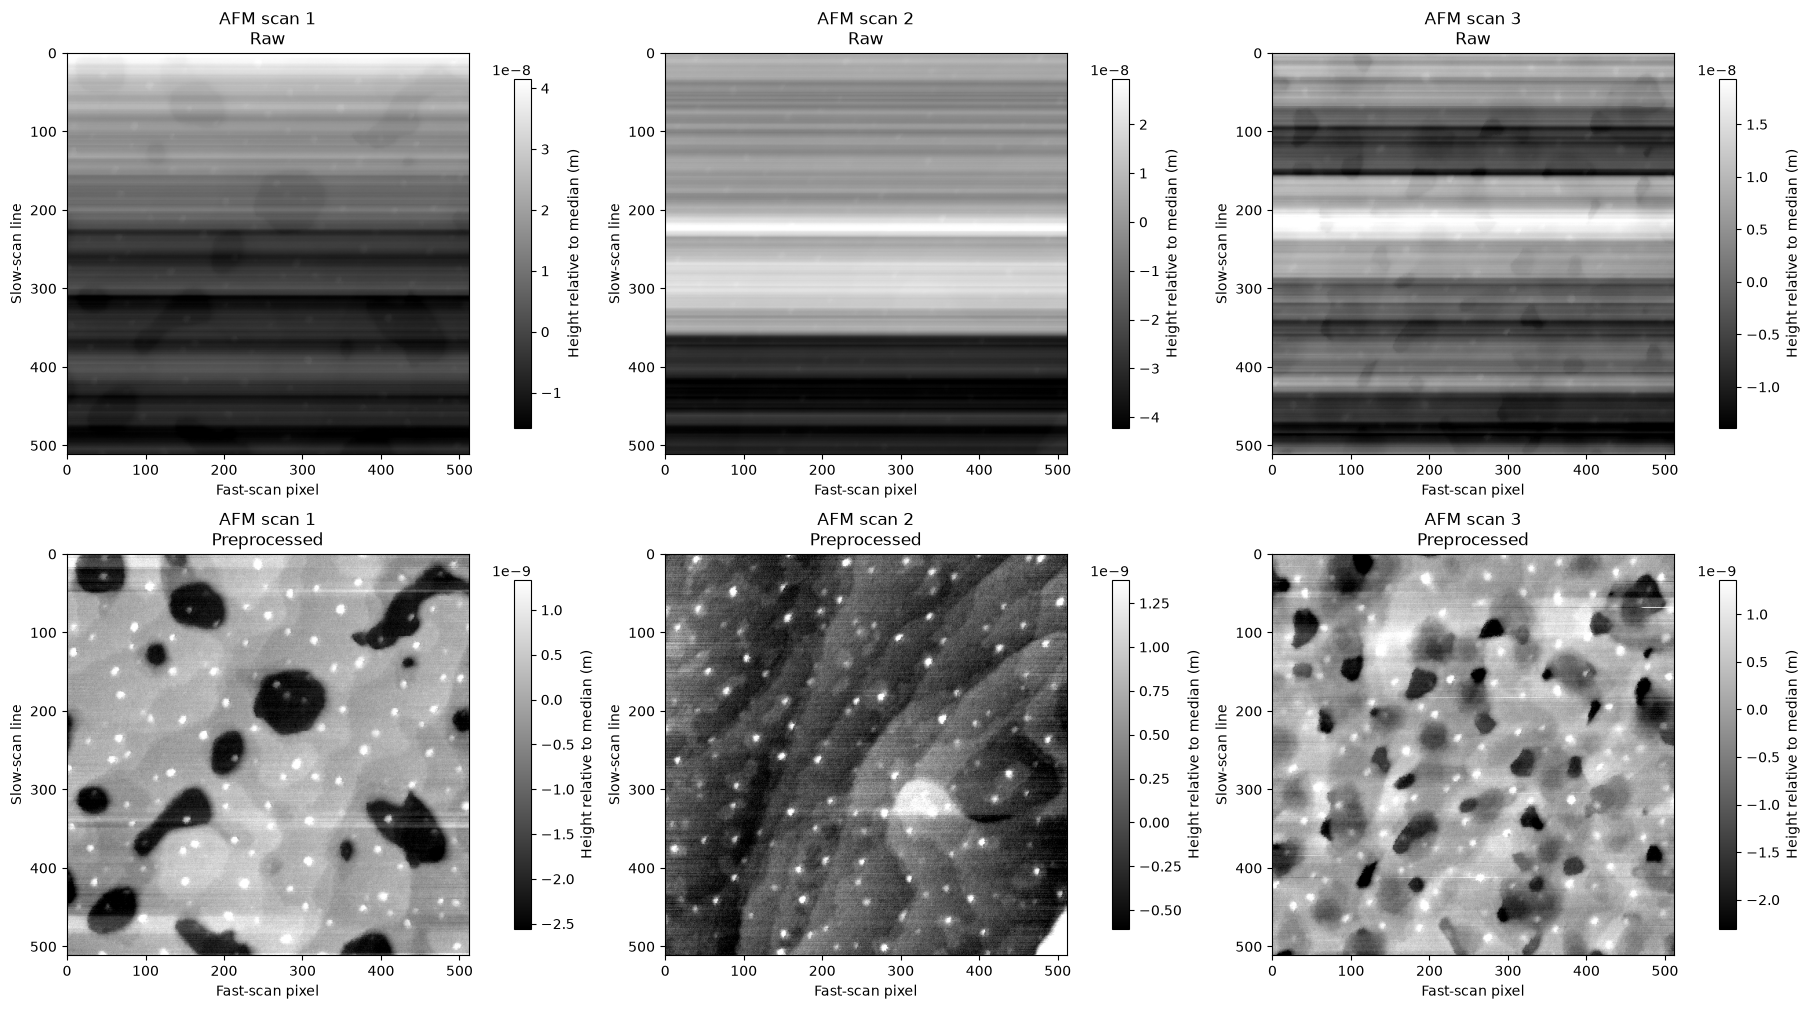

In [10]:
raw_scans = []
processed_scans = []

for path in afm_files:
    z = np.load(path)
    z = np.asarray(z, dtype=float)

    z_processed, stages = dp.preprocess_afm(
        z,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    raw_scans.append(z)
    processed_scans.append(z_processed)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    constrained_layout=True,
)

for column, (raw, processed, title) in enumerate(
    zip(raw_scans, processed_scans, titles)
):
    raw_display = raw - np.nanmedian(raw)

    raw_vmin, raw_vmax = np.nanpercentile(
        raw_display,
        [1, 99],
    )

    raw_image = axes[0, column].imshow(
        raw_display,
        cmap="gray",
        vmin=raw_vmin,
        vmax=raw_vmax,
        origin="upper",
    )

    axes[0, column].set_title(f"{title}\nRaw")
    axes[0, column].set_xlabel("Fast-scan pixel")
    axes[0, column].set_ylabel("Slow-scan line")

    fig.colorbar(
        raw_image,
        ax=axes[0, column],
        label="Height relative to median (m)",
        shrink=0.85,
    )

    processed_vmin, processed_vmax = np.nanpercentile(
        processed,
        [1, 99],
    )

    processed_image = axes[1, column].imshow(
        processed,
        cmap="gray",
        vmin=processed_vmin,
        vmax=processed_vmax,
        origin="upper",
    )

    axes[1, column].set_title(f"{title}\nPreprocessed")
    axes[1, column].set_xlabel("Fast-scan pixel")
    axes[1, column].set_ylabel("Slow-scan line")

    fig.colorbar(
        processed_image,
        ax=axes[1, column],
        label="Height relative to median (m)",
        shrink=0.85,
    )

plt.show()

# Ground Truth Blobs Labelled

Taken from Chenuye's Dataset

### Ground-truth scan images

<p align="center">
  <img src="Ground-Truth/Images/AIX6461_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
  <img src="Ground-Truth/Images/AIX6468_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
  <img src="Ground-Truth/Images/AIX6470_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
</p>

### Labelled Ground-truth set

<p align="center">
  <img src="Ground-Truth/Images/LabelledQDs.png" width="100%">
</p>